# Priprema podataka:

In [5]:
import os
os.chdir('/home/lenovo/ip2/archive/csv')
print("Radni direktorijum:", os.getcwd())

Radni direktorijum: /home/lenovo/ip2/archive/csv


**Import biblioteka:**

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [7]:
combine     = pd.read_csv('draft_combine_stats.csv')
player_info = pd.read_csv('common_player_info.csv')


#spajamo podatke
df = combine.merge(
    player_info[['person_id', 'position']],
    left_on='player_id', right_on='person_id', how='left'
)

#biramo atribute za klasterovanje
features = [
    'height_wo_shoes', 'weight', 'wingspan', 'standing_reach',
    'body_fat_pct', 'standing_vertical_leap', 'max_vertical_leap',
    'lane_agility_time', 'three_quarter_sprint'
]

#rad sa nedostajucim podacima
# zadrži red samo ako ima popunjeno najmanje 7 od 9 atributa
#preostale NaN vrednosti (0, 1 ili 2 po igraču) popunjavamo medijanom te kolone
#medijana je bolja od proseka jer nije osetljiva na ekstremne vrednosti

df_clean = df.dropna(subset=features, thresh=len(features)-2).copy()
for col in features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
df_clean = df_clean.reset_index(drop=True)

print(f"Broj igrača: {len(df_clean)}")
df_clean[features].describe()


Broj igrača: 1016


,height_wo_shoes,weight,wingspan,standing_reach,body_fat_pct,standing_vertical_leap,max_vertical_leap,lane_agility_time,three_quarter_sprint
count,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000
mean,77.495079,214.749803,82.385925,103.432480,7.256270,29.245817,34.641240,11.383701,3.282018
std,3.329481,25.590294,3.927601,4.817665,2.535072,3.053250,3.647589,0.582591,0.131521
min,67.750000,154.400000,70.750000,89.500000,2.600000,20.500000,25.000000,9.650000,2.910000
25%,75.250000,196.000000,80.000000,100.000000,5.600000,27.000000,32.000000,10.970000,3.190000
50%,77.750000,212.800000,82.750000,104.000000,6.700000,29.000000,34.500000,11.320000,3.270000
75%,80.000000,233.000000,85.250000,107.000000,8.125000,31.500000,37.000000,11.710000,3.360000
max,89.250000,314.000000,98.250000,122.500000,21.000000,39.500000,45.500000,13.440000,3.810000


In [5]:
#standardizacija
X_scaled = StandardScaler().fit_transform(df_clean[features])

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print(f"Objašnjena varijansa PC1+PC2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

player_names = df_clean['player_name'].values

Objašnjena varijansa PC1+PC2: 72.8%


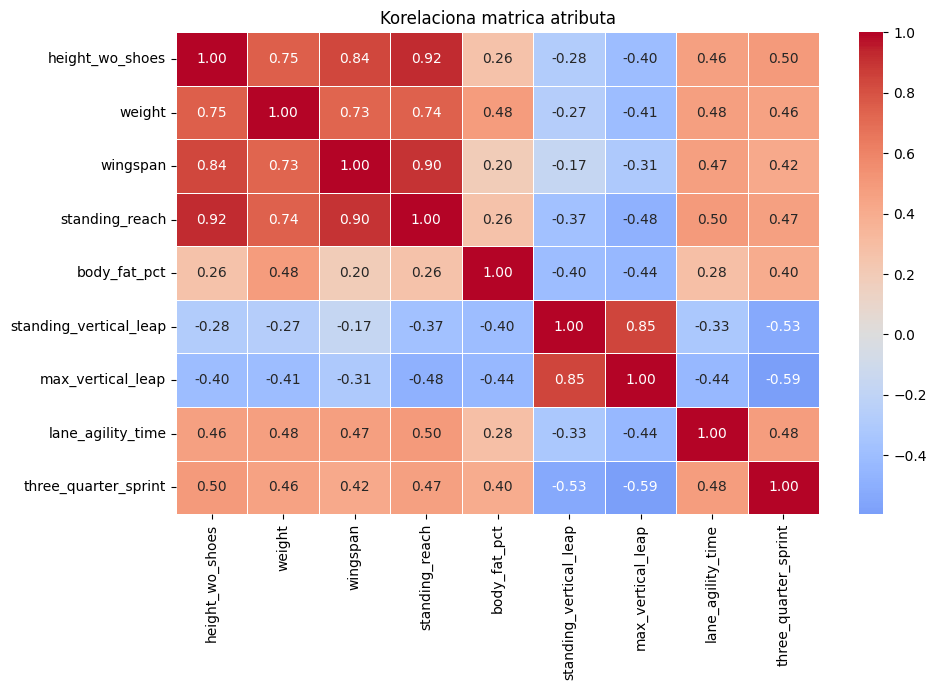

In [6]:
# Korelaciona matrica atributa
plt.figure(figsize=(10, 7))
sns.heatmap(df_clean[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Korelaciona matrica atributa')
plt.tight_layout()
plt.show()

# 1. Agglomerative Clustering

Agglomerative Clustering je `hijerarhijski` algoritam koji kreće od dna:

    1. Svaka tačka počinje kao zaseban klaster
    2. U svakom koraku spajaju se dva najbliža klastera
    3. Ponavljamo dok ne dobijemo n_clusters klastera

Parametar `linkage` određuje kako se meri rastojanje između klastera:

   - `ward` – minimizuje varijansu unutar klastera (najčešće se koristi)
   - `complete` – maksimalno rastojanje između tačaka
   - `average` – prosečno rastojanje između tačaka
   - `single` – minimalno rastojanje između tačaka

Rezultat se može prikazati kao dendogram – stablo spajanja klastera.

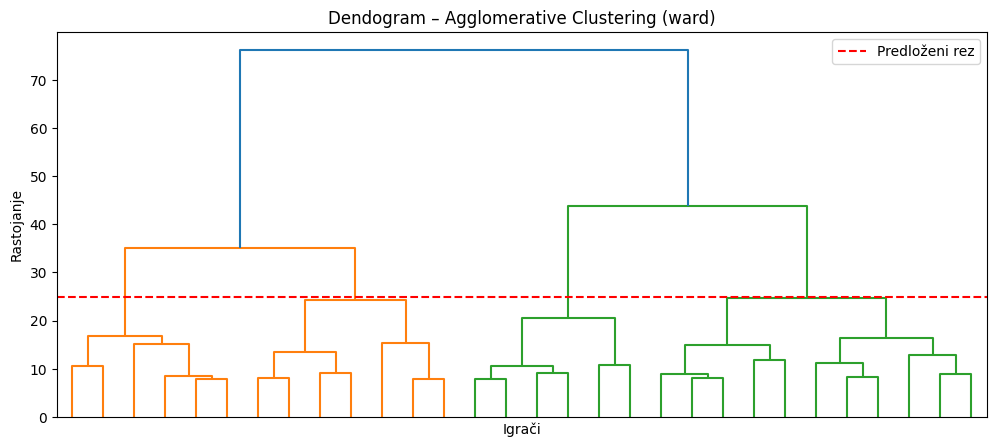

In [7]:
# Dendogram za određivanje broja klastera
from scipy.cluster.hierarchy import linkage

linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, no_labels=True)
plt.axhline(y=25, color='red', linestyle='--', label='Predloženi rez')
plt.xlabel('Igrači')
plt.ylabel('Rastojanje')
plt.title('Dendogram – Agglomerative Clustering (ward)')
plt.legend()
plt.show()

In [8]:
from sklearn.cluster import AgglomerativeClustering
# linkage moze biti 'single', 'complete', 'average', 'ward'
ac = AgglomerativeClustering(n_clusters=3, linkage='ward')
ac_fitted_data = ac.fit(X_scaled)

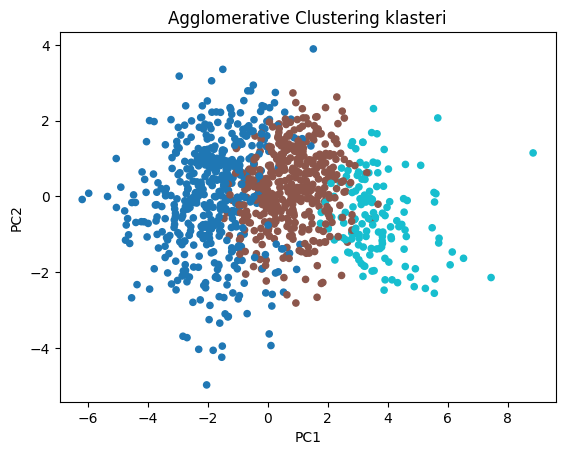

In [9]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=ac.labels_, cmap='tab10', s=20)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Agglomerative Clustering klasteri')
plt.show()


n_clusters=2: silhouette=0.2533
n_clusters=3: silhouette=0.1890
n_clusters=4: silhouette=0.1483
n_clusters=5: silhouette=0.1175
n_clusters=6: silhouette=0.1148
n_clusters=7: silhouette=0.1142
n_clusters=8: silhouette=0.0990
n_clusters=9: silhouette=0.0909


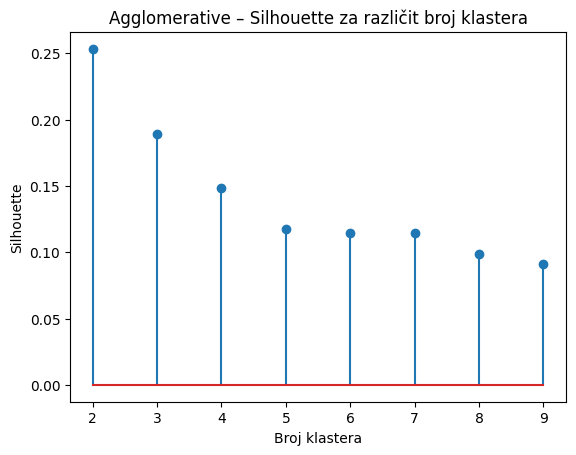

In [10]:
# Silhouette analiza za izbor broja klastera
silhouettes_ac = []
for n in range(2, 10):
    ac_tmp = AgglomerativeClustering(n_clusters=n, linkage='ward')
    lbl    = ac_tmp.fit_predict(X_scaled)
    s      = silhouette_score(X_scaled, lbl)
    silhouettes_ac.append(s)
    print(f"n_clusters={n}: silhouette={s:.4f}")

plt.stem(range(2, 10), silhouettes_ac)
plt.xlabel('Broj klastera')
plt.ylabel('Silhouette')
plt.title('Agglomerative – Silhouette za različit broj klastera')
plt.show()

In [11]:
best_k_ac = range(2, 10)[np.argmax(silhouettes_ac)]
print(f"Izabrani broj klastera: {best_k_ac}")

ac     = AgglomerativeClustering(n_clusters=best_k_ac, linkage='ward')
labels_ac = ac.fit_predict(X_scaled)

sil_ac = silhouette_score(X_scaled, labels_ac)
print(f"Silhouette koeficijent: {sil_ac:.4f}")

Izabrani broj klastera: 2
Silhouette koeficijent: 0.2533


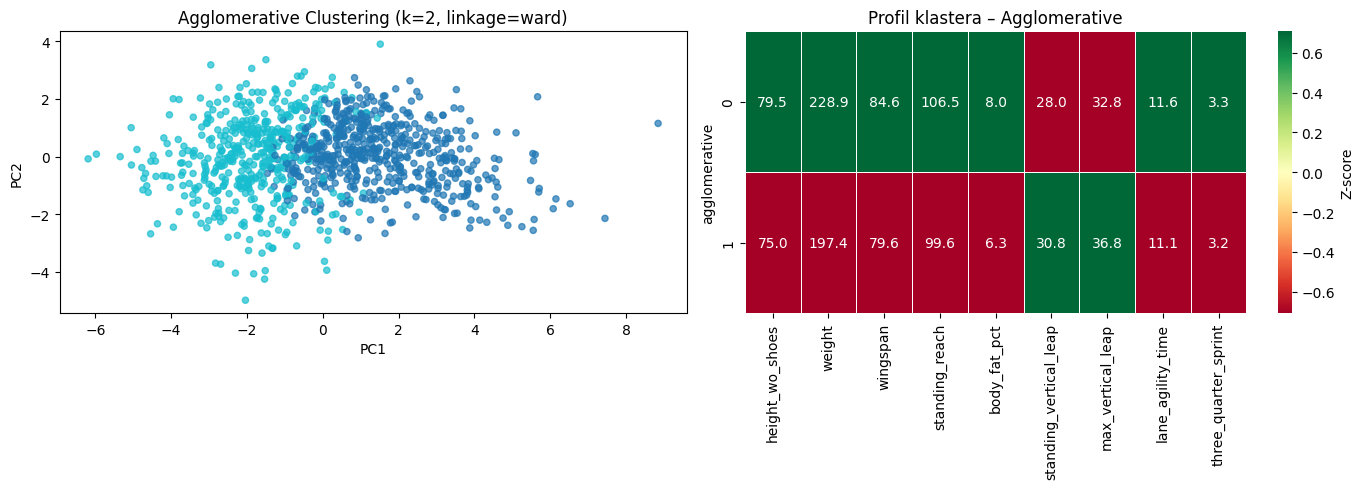

In [12]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_ac, cmap='tab10', s=20, alpha=0.7)
plt.title(f'Agglomerative Clustering (k={best_k_ac}, linkage=ward)')
plt.xlabel('PC1'); plt.ylabel('PC2')

plt.subplot(1, 2, 2)
df_clean['agglomerative'] = labels_ac
stats_ac = df_clean.groupby('agglomerative')[features].mean().round(1)
sns.heatmap((stats_ac - stats_ac.mean()) / stats_ac.std(), annot=stats_ac, fmt='.1f',
            cmap='RdYlGn', center=0, linewidths=0.5, cbar_kws={'label': 'Z-score'})
plt.title('Profil klastera – Agglomerative')
plt.tight_layout()
plt.show()


In [13]:
pd.Series(labels_ac).value_counts()

0    560
1    456
Name: count, dtype: int64